In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [2]:
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [3]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [17]:
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)
p_both_heads = np.mean(heads == 2)
print("P(both heads):", p_both_heads)
p_at_least_one = np.mean(heads >= 1)
print("P(at least one head):", p_at_least_one)
p_0 = np.mean(heads == 0)
p_1 = np.mean(heads == 1)
p_2 = np.mean(heads == 2)

print("P(0 heads):", p_0)
print("P(1 head):", p_1)
print("P(2 heads):", p_2)
print("Sum:", p_0 + p_1 + p_2)

P(both heads): 0.24913
P(at least one head): 0.74987
P(0 heads): 0.25013
P(1 head): 0.50074
P(2 heads): 0.24913
Sum: 0.9999999999999999


In [5]:
rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [6]:
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


In [18]:
rolls = np.random.randint(1, 7, size=100_000)
condition = rolls < 4
p_odd_given_less4 = np.mean(rolls[condition] % 2 == 1)
print("P(odd | roll < 4):", p_odd_given_less4)
p_less4 = np.mean(rolls < 4)
print("P(roll < 4):", p_less4)
p_odd = np.mean(rolls % 2 == 1)
print("P(odd):", p_odd)

print("Independent?", np.isclose(p_odd_given_less4, p_odd))

P(odd | roll < 4): 0.6659028782762502
P(roll < 4): 0.49752
P(odd): 0.49809
Independent? False


In [8]:
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')


P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [9]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)
among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.503


In [19]:
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
pois = stats.poisson(mu=4).rvs(size=10_000)
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05
p_ham = 1 - p_spam

p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print("P('free'):", p_free)
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print("P(spam | 'free'):", p_spam_given_free)


P('free'): 0.16
P(spam | 'free'): 0.75


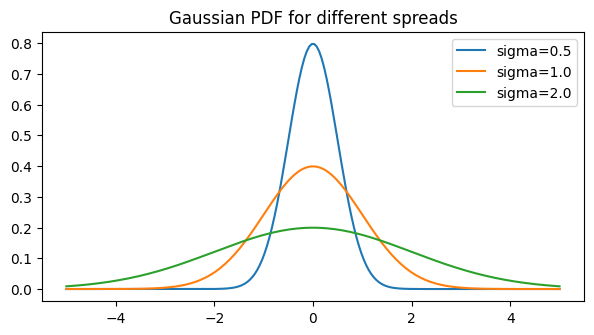

In [12]:
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Sample mean: 2.0053


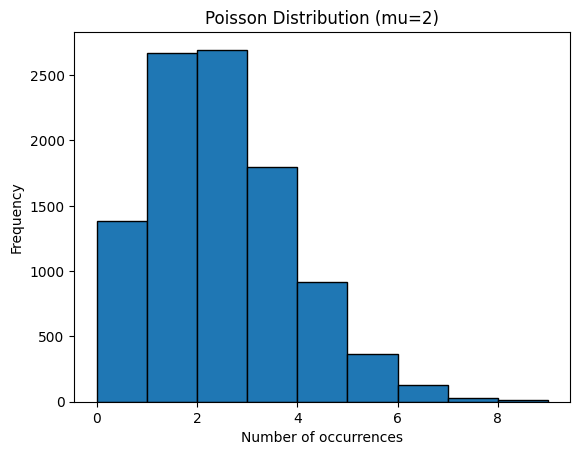

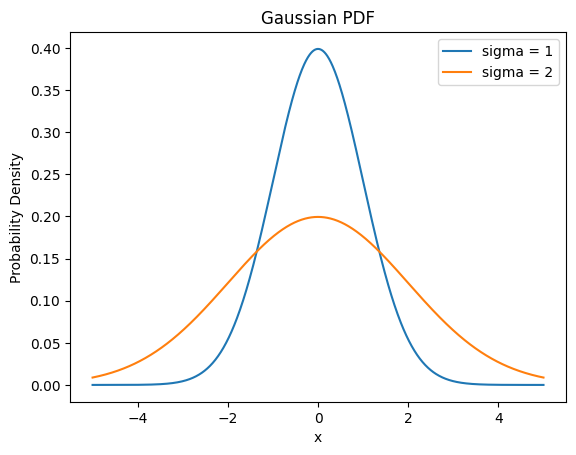

In [22]:
import numpy as np
import matplotlib.pyplot as plt
samples = np.random.poisson(2, 10000)
print("Sample mean:", np.mean(samples))
plt.hist(samples, bins=range(0, 10), edgecolor="black")
plt.xlabel("Number of occurrences")
plt.ylabel("Frequency")
plt.title("Poisson Distribution (mu=2)")
plt.show()
x = np.linspace(-5, 5, 1000)
mu = 0
sigma1 = 1
y1 = (1 / (sigma1 * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma1 ** 2))
sigma2 = 2
y2 = (1 / (sigma2 * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma2 ** 2))
plt.plot(x, y1, label="sigma = 1")
plt.plot(x, y2, label="sigma = 2")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Gaussian PDF")
plt.legend()
plt.show()

In [13]:
from scipy.stats import entropy

fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')


Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [14]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [15]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [23]:
import numpy as np
die4 = np.array([1/4] * 4)
die6 = np.array([1/6] * 6)

entropy4 = -np.sum(die4 * np.log2(die4))
entropy6 = -np.sum(die6 * np.log2(die6))

print("Entropy of 4-sided die:", entropy4, "bits")
print("Entropy of 6-sided die:", entropy6, "bits")
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

kl = np.sum(P * np.log2(P / Q))

print("KL Divergence D(P || Q):", kl, "bits")

Entropy of 4-sided die: 2.0 bits
Entropy of 6-sided die: 2.584962500721156 bits
KL Divergence D(P || Q): 0.1187091007693073 bits
